In [2]:
pip install emcee

  Obtaining dependency information for emcee from https://files.pythonhosted.org/packages/f9/ef/2196b9bf88ffa1bde45853c72df021fbd07a8fa91a0f59a22d14a050dc04/emcee-3.1.6-py2.py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.4 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install corner

  Obtaining dependency information for corner from https://files.pythonhosted.org/packages/d6/cb/17a130e548ee1777f2a66e09240c531a9bf79454add7ef1198fe1e41c412/corner-2.3.0-py3-none-any.whl.metadata
  Obtaining dependency information for matplotlib>=2.1 from https://files.pythonhosted.org/packages/0b/d7/59d8ee63e4dee845d953515c50d67e6b8cefa953b453c6b803f197ae556e/matplotlib-3.11.2-cp311-cp311-macosx_11_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 1.8 MB/s eta 0:00:00a 0:00:01
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/0d/44/c4b0b6095fef4dc9c420e041799591e3b63e9619e3044f7f4f6c21c0ab24/contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Obtaining dependency information for fonttools>=4.28.

In [3]:
pip install sbi

  Obtaining dependency information for sbi from https://files.pythonhosted.org/packages/67/72/1a7b04d07ea9fb4a7c09831f0f7612017afe54b7b585161bfbfef161c152/sbi-0.27.0-py3-none-any.whl.metadata
  Obtaining dependency information for joblib>=1.0.0 from https://files.pythonhosted.org/packages/18/53/84099323c2ec4be98d935f63c033ac4151ee83836ca1050ede3b3aadf155/joblib-1.6.0-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 6.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/23/31/dc50d8780ac647bed9417f10a8b15ae3cf990ad7edb4f4b468f35030f8c5/scikit_learn-1.9.1-cp311-cp311-macosx_12_0_arm64.whl.metadata
  Obtaining dependency information for scipy from https://files.pythonhosted.org/packages/f7/58/bccc2861b305abdd1b8663d6130c0b3d7cc22e8d86663edbc8401bfd40d4/scipy-

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy as sp
from scipy.stats import beta
import emcee as mcmc
import corner as cp
import sbi
from sbi.inference import NPE, simulate_for_sbi
from sbi import analysis as analysis
from sbi import utils as utils
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
import math
import os
import torch


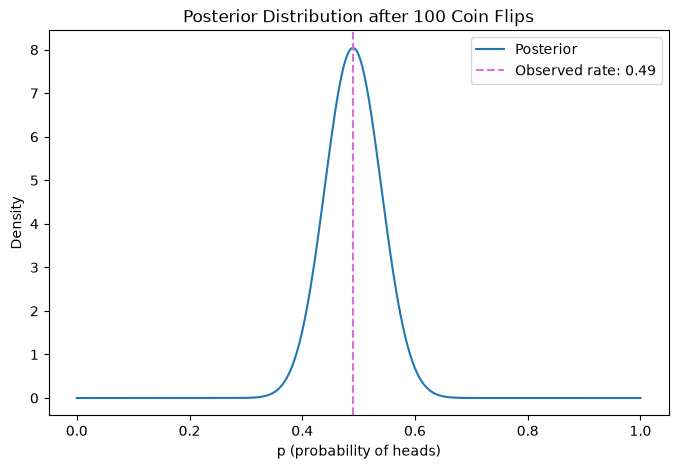

Heads: 49, Tails: 51
Posterior mean: 0.490


In [54]:
coin_bias = 0.5
n_flips = 100
flips = np.random.binomial(1, coin_bias, n_flips)
heads = flips.sum()
tails = n_flips - heads

a_prior, b_prior = 1, 1          
a_post = a_prior + heads
b_post = b_prior + tails

x = np.linspace(0, 1, 500)
posterior = beta.pdf(x, a_post, b_post)

plt.figure(figsize=(8, 5))
plt.plot(x, posterior, label=f'Posterior')
plt.axvline(heads/n_flips, color = 'orchid', linestyle='--', label=f'Observed rate: {heads/n_flips:.2f}')
plt.title(f'Posterior Distribution after {n_flips} Coin Flips')
plt.xlabel('p (probability of heads)')
plt.ylabel('Density')
plt.legend()
plt.show()

print(f"Heads: {heads}, Tails: {tails}")
print(f"Posterior mean: {a_post / (a_post + b_post):.3f}")

Coin bias=0.3 -> Heads: 31, Tails: 69, Posterior mean: 0.327
Coin bias=0.5 -> Heads: 60, Tails: 40, Posterior mean: 0.591
Coin bias=0.7 -> Heads: 71, Tails: 29, Posterior mean: 0.691


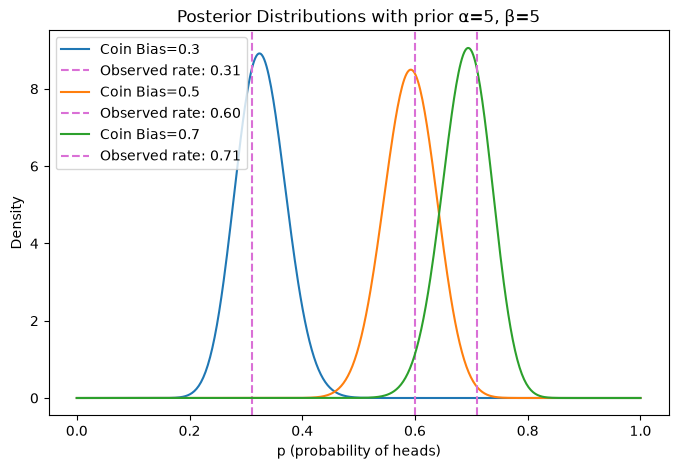

In [55]:
coin_bias = (0.3, 0.5, 0.7)
n_flips = 100
a_prior, b_prior = 5, 5

x = np.linspace(0, 1, 500)

plt.figure(figsize=(8, 5))

for num in coin_bias:
    flips = np.random.binomial(1, num, n_flips)
    heads = flips.sum()
    tails = n_flips - heads

    a_post = a_prior + heads
    b_post = b_prior + tails

    posterior = beta.pdf(x, a_post, b_post)

    plt.plot(x, posterior, label=f'Coin Bias={num}')
    plt.axvline(heads/n_flips, color = 'orchid', linestyle='--', label=f'Observed rate: {heads/n_flips:.2f}')
    print(f"Coin bias={num} -> Heads: {heads}, Tails: {tails}, "
          f"Posterior mean: {a_post / (a_post + b_post):.3f}")

plt.title(f'Posterior Distributions with prior α={a_prior}, β={b_prior}')
plt.xlabel('p (probability of heads)')
plt.ylabel('Density')
plt.legend()
plt.show()

Coin flips=10 -> Heads: 5, Tails: 5, Posterior mean: 0.500
Coin flips=100 -> Heads: 49, Tails: 51, Posterior mean: 0.491
Coin flips=1000 -> Heads: 513, Tails: 487, Posterior mean: 0.513


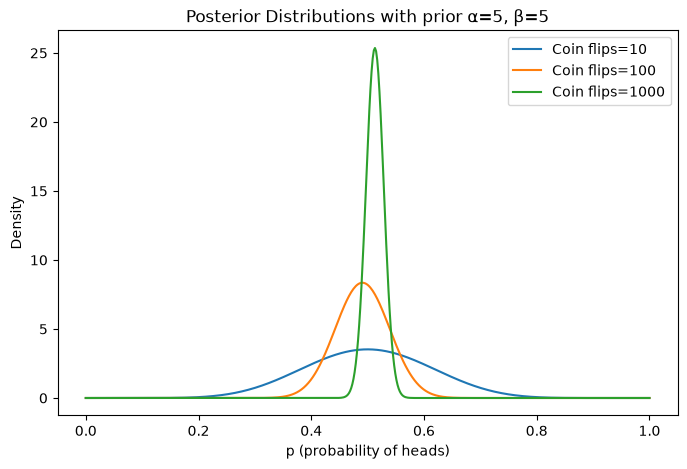

In [56]:
coin_bias = 0.5
n_flips = (10, 100, 1000)
a_prior, b_prior = 5, 5

x = np.linspace(0, 1, 500)

plt.figure(figsize=(8, 5))

for num in n_flips:
    flips = np.random.binomial(1, coin_bias, num)
    heads = flips.sum()
    tails = num - heads

    a_post = a_prior + heads
    b_post = b_prior + tails

    posterior = beta.pdf(x, a_post, b_post)

    plt.plot(x, posterior, label=f'Coin flips={num}')
    print(f"Coin flips={num} -> Heads: {heads}, Tails: {tails}, "
          f"Posterior mean: {a_post / (a_post + b_post):.3f}")

plt.title(f'Posterior Distributions with prior α={a_prior}, β={b_prior}')
plt.xlabel('p (probability of heads)')
plt.ylabel('Density')
plt.legend()
plt.show()

In [58]:
pip install scikit-learn


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


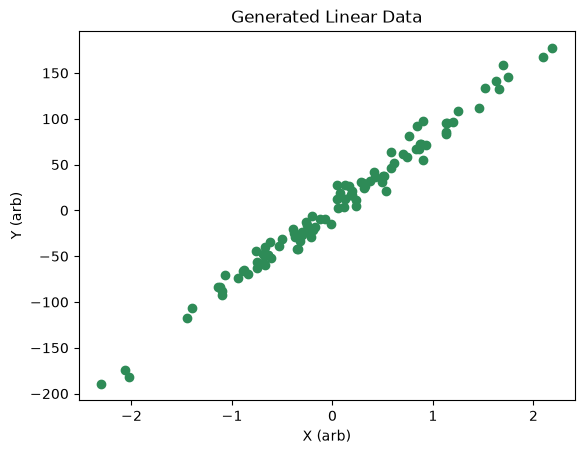

In [79]:
from sklearn.datasets import make_regression

X, Y = make_regression(n_samples=100, n_features=1, noise=10, random_state=1)
plt.plot(X[:, 0], Y, 'o', color = 'seagreen')
plt.title('Generated Linear Data')
plt.xlabel('X (arb)')
plt.ylabel('Y (arb)')
plt.show()

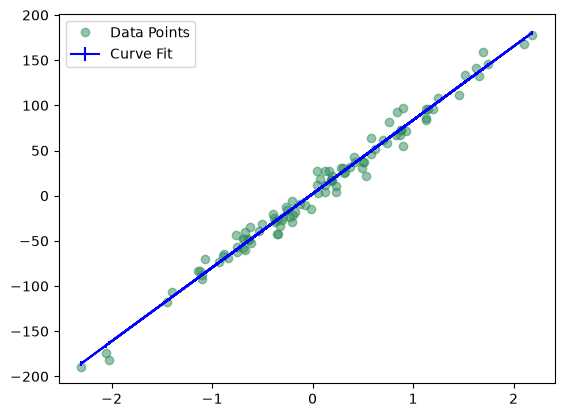

In [91]:
#Method 1: Curve fitting
def linear_model(x, a, b):
    return a*x + b

popt, pcov = sp.optimize.curve_fit(linear_model, X[:, 0], Y) 
a, b = popt
var_a, var_b = np.diag(pcov)
cov_ab = pcov[0, 1]
pvar = np.diag(pcov)

y_fit = linear_model(X[:, 0], *popt)
#error:
y_err = np.sqrt(X[:, 0]**2 * var_a + var_b + 2 * X[:, 0] * cov_ab)
plt.plot(X[:, 0], Y, 'o', color = 'seagreen',alpha=0.5, label='Data Points')
plt.errorbar(X[:, 0], y_fit, y_err, color='blue', label='Curve Fit')
plt.legend()



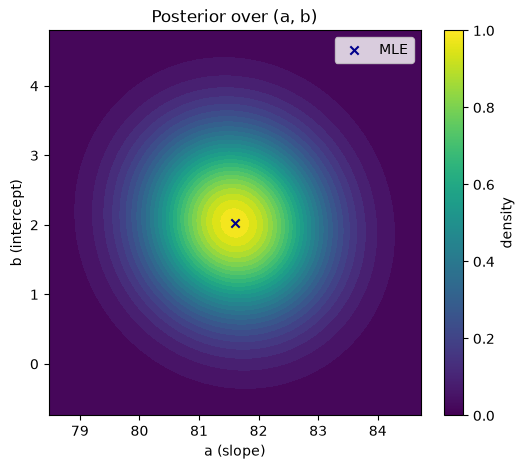

In [ ]:
#Posterior implied by MLE and covariance matrix
a_std, b_std = np.sqrt(np.diag(pcov))
a_grid = np.linspace(a - 3*a_std, a + 3*a_std, 100)
b_grid = np.linspace(b - 3*b_std, b + 3*b_std, 100)
A, B = np.meshgrid(a_grid, b_grid)

pos = np.dstack((A, B))
rv = sp.stats.multivariate_normal(mean=popt, cov=pcov)
Z = rv.pdf(pos)

plt.figure(figsize=(6, 5))
plt.contourf(A, B, Z, levels=30)
plt.scatter(*popt, color='darkblue', marker='x', label='MLE')
plt.xlabel('a (slope)')
plt.ylabel('b (intercept)')
plt.title('Posterior over (a, b)')
plt.legend()
plt.colorbar(label='density')
plt.show()

In [ ]:
from sbi.inference import NPE

# define shifted Gaussian simulator.
def simulator(θ): return θ + torch.randn_like(θ)
# draw parameters from Gaussian prior.
θ = torch.randn(1000, 2)
# simulate data
x = simulator(θ)

# choose sbi method and train
inference = NPE()
inference.append_simulations(θ, x).train()

# do inference given observed data
x_o = torch.ones(2)
posterior = inference.build_posterior()
samples = posterior.sample((1000,), x=x_o)

 Neural network successfully converged after 341 epochs.

  0%|          | 0/1000 [00:00<?, ?it/s]

## sbi package example

In [ ]:
pip install pyro

  Preparing metadata (setup.py) ... error
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [7 lines of output]
      Traceback (most recent call last):
        File "<string>", line 2, in <module>
        File "<pip-setuptools-caller>", line 35, in <module>
        File "/tmp/pip-install-w7y_4_8o/pyro_d5ec84072c7a4a8186d36073e05de2b1/setup.py", line 23
          exec code in constants
          ^^^^^^^^^^^^^^^^^^^^^^
      SyntaxError: Missing parentheses in call to 'exec'. Did you mean exec(...)?
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import matplotlib.pyplot as plt
import torch
from example_01_utils import BinomialGammaPotential
from pyro.distributions import InverseGamma
from torch import Tensor
from torch.distributions import Beta, Binomial, Gamma

from sbi.analysis import pairplot
from sbi.inference import MNLE, MCMCPosterior
from sbi.inference.posteriors.posterior_parameters import MCMCPosteriorParameters
from sbi.inference.potentials.likelihood_based_potential import LikelihoodBasedPotential
from sbi.neural_nets import likelihood_nn
from sbi.utils import BoxUniform, MultipleIndependent, mcmc_transform
from sbi.utils.metrics import c2st

ModuleNotFoundError: No module named 'pyro'